# Cookie Cats: Should We Move the Gate?
## An End-to-End A/B Test Analysis

**Author**: Yidan Xiong
**Date**: May 2026
**Repository**: [github.com/malaxiongxiong/cookie-cats-ab-test](https://github.com/malaxiongxiong/cookie-cats-ab-test)

---

## 📌 Project Overview

This notebook walks through a complete A/B test analysis on the Cookie Cats mobile game dataset. The product team wants to know: **should we move the first gate from level 30 to level 40 to improve player retention?**

### Analysis Workflow

1. **Problem Framing & Hypothesis** — Define H0/H1 and metrics
2. **Power Analysis** — Calculate required sample size
3. **EDA & Sanity Checks** — Explore data and verify randomization (SRM test)
4. **Statistical Testing** — Two-proportion z-test on retention metrics
5. **Segment Analysis** — Investigate heterogeneous treatment effects
6. **Recommendation** — Translate findings into a business decision

---

In [1]:
# === Data manipulation ===
import pandas as pd
import numpy as np

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Statistics & A/B testing ===
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

# === Display settings ===
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimal places for floats
sns.set_style('whitegrid')  # Clean chart background
plt.rcParams['figure.figsize'] = (10, 6)  # Default chart size

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# Mount Google Drive to access files stored there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# === Load the dataset from Google Drive ===
# File is in My Drive root directory
file_path = '/content/drive/MyDrive/cookie_cats.csv'

df = pd.read_csv(file_path)

# Step 1 of EDA: Check the shape
print(f"Dataset shape: {df.shape}")
print(f"  → {df.shape[0]:,} rows")
print(f"  → {df.shape[1]} columns")

Dataset shape: (90189, 5)
  → 90,189 rows
  → 5 columns


In [4]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [6]:
# Step 4 of EDA: Check group sizes
# This is critical for A/B testing - we need to verify randomization
group_counts = df['version'].value_counts()
group_proportions = df['version'].value_counts(normalize=True)

print("Group sizes:")
print(group_counts)
print("\nGroup proportions:")
print(group_proportions)

Group sizes:
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Group proportions:
version
gate_40   0.5044
gate_30   0.4956
Name: proportion, dtype: float64


In [7]:
# Step 5 of EDA: Check retention rates overall and by group
print("=== Overall retention rates ===")
print(f"retention_1: {df['retention_1'].mean():.2%}")
print(f"retention_7: {df['retention_7'].mean():.2%}")

print("\n=== Retention rates by group ===")
print(df.groupby('version')[['retention_1', 'retention_7']].mean())

=== Overall retention rates ===
retention_1: 44.52%
retention_7: 18.61%

=== Retention rates by group ===
         retention_1  retention_7
version                          
gate_30       0.4482       0.1902
gate_40       0.4423       0.1820


In [8]:
# Step 6 of EDA: Inspect sum_gamerounds distribution
# This is critical because outliers in continuous metrics can heavily distort analysis

print("=== sum_gamerounds: Basic statistics ===")
print(df['sum_gamerounds'].describe())

print("\n=== sum_gamerounds: Additional percentiles ===")
percentiles = [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
print(df['sum_gamerounds'].quantile(percentiles))

=== sum_gamerounds: Basic statistics ===
count   90189.0000
mean       51.8725
std       195.0509
min         0.0000
25%         5.0000
50%        16.0000
75%        51.0000
max     49854.0000
Name: sum_gamerounds, dtype: float64

=== sum_gamerounds: Additional percentiles ===
0.5000     16.0000
0.7500     51.0000
0.9000    134.0000
0.9500    221.0000
0.9900    493.0000
0.9990   1073.6240
Name: sum_gamerounds, dtype: float64


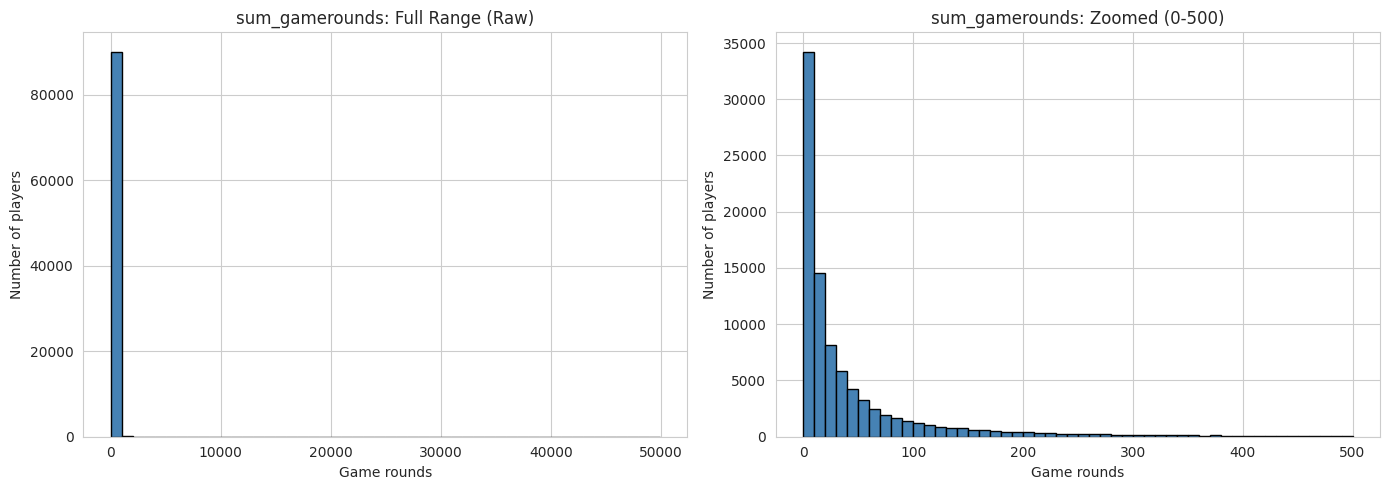

In [9]:
# Step 7 of EDA: Visualize sum_gamerounds distribution
# A histogram makes outliers visually obvious

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Full range (will be dominated by outliers)
axes[0].hist(df['sum_gamerounds'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('sum_gamerounds: Full Range (Raw)')
axes[0].set_xlabel('Game rounds')
axes[0].set_ylabel('Number of players')

# Right plot: Zoom in to 0-500 to see the actual distribution shape
axes[1].hist(df['sum_gamerounds'], bins=50, range=(0, 500),
             color='steelblue', edgecolor='black')
axes[1].set_title('sum_gamerounds: Zoomed (0-500)')
axes[1].set_xlabel('Game rounds')
axes[1].set_ylabel('Number of players')

plt.tight_layout()
plt.show()

In [10]:
# How many "extreme" players are there at each threshold?
thresholds = [500, 1000, 2000, 5000, 10000]

print("=== How many players exceed each threshold? ===\n")
for t in thresholds:
    count = (df['sum_gamerounds'] > t).sum()
    pct = count / len(df) * 100
    print(f"  > {t:>6,} rounds:  {count:>5,} players  ({pct:.3f}%)")

=== How many players exceed each threshold? ===

  >    500 rounds:    856 players  (0.949%)
  >  1,000 rounds:    116 players  (0.129%)
  >  2,000 rounds:     10 players  (0.011%)
  >  5,000 rounds:      1 players  (0.001%)
  > 10,000 rounds:      1 players  (0.001%)


In [11]:
# Step 8 of EDA: Cap outliers at the 99.5th percentile (non-destructive)

# Find the 99.5th percentile threshold
p995 = df['sum_gamerounds'].quantile(0.995)
print(f"99.5th percentile of sum_gamerounds: {p995:.0f} rounds")
print(f"Players above 99.5th percentile: {(df['sum_gamerounds'] > p995).sum():,}")

# Create a cleaned copy (DO NOT modify original df)
df_clean = df.copy()

# Cap (Winsorize) values above the 99.5th percentile
df_clean['sum_gamerounds'] = df_clean['sum_gamerounds'].clip(upper=p995)

# Verify the result
print(f"\n=== After capping ===")
print(f"Original max: {df['sum_gamerounds'].max():,}")
print(f"Cleaned max:  {df_clean['sum_gamerounds'].max():.0f}")
print(f"Original mean: {df['sum_gamerounds'].mean():.2f}")
print(f"Cleaned mean:  {df_clean['sum_gamerounds'].mean():.2f}")
print(f"Original std:  {df['sum_gamerounds'].std():.2f}")
print(f"Cleaned std:   {df_clean['sum_gamerounds'].std():.2f}")

99.5th percentile of sum_gamerounds: 623 rounds
Players above 99.5th percentile: 451

=== After capping ===
Original max: 49,854
Cleaned max:  623
Original mean: 51.87
Cleaned mean:  49.93
Original std:  195.05
Cleaned std:   89.60


### Outlier Handling for `sum_gamerounds`

The distribution of `sum_gamerounds` is heavily right-skewed, with a maximum of 49,854 rounds — likely a bot or test account. About 451 players (0.5%) exceed the 99.5th percentile of 623 rounds.

**Decision**: Cap values at the **99.5th percentile** (Winsorization) rather than dropping rows. This reduces the standard deviation by 54% while keeping the mean nearly unchanged — preserving the signal while killing the noise from extreme values.

**Why not delete?** Dropped rows might represent real high-engagement users, not just bots. Capping is a less destructive choice that preserves all 90,189 observations.

**Implementation**: The original `df` is preserved untouched (binary metrics like `retention_1` are unaffected by outliers anyway). A separate `df_clean` is used wherever `sum_gamerounds` analysis is involved.

In [12]:
# === Step 3: SRM Sanity Check ===
# Verify that the actual group split matches the designed 50/50 allocation
# A failed SRM invalidates the entire experiment

# Step 1: Get observed group sizes
observed = df['version'].value_counts().sort_index()
print("Observed group sizes:")
print(observed)

# Step 2: Calculate expected sizes (50/50 split)
total_users = len(df)
expected = pd.Series([total_users / 2, total_users / 2],
                     index=['gate_30', 'gate_40'])
print("\nExpected group sizes (under 50/50 design):")
print(expected)

# Step 3: Run chi-square test
chi2_stat, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f"\n=== SRM Chi-Square Test ===")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"P-value:              {p_value:.4f}")

# Step 4: Interpret result with the industry-standard threshold
srm_threshold = 0.0001
if p_value < srm_threshold:
    print(f"\n🚨 SRM DETECTED (p < {srm_threshold})")
    print("   The experiment may be compromised. Investigate routing before analyzing results.")
else:
    print(f"\n✅ SRM PASSED (p >= {srm_threshold})")
    print("   Group split is consistent with random 50/50 allocation. Safe to proceed.")

Observed group sizes:
version
gate_30    44700
gate_40    45489
Name: count, dtype: int64

Expected group sizes (under 50/50 design):
gate_30   45094.5000
gate_40   45094.5000
dtype: float64

=== SRM Chi-Square Test ===
Chi-square statistic: 6.9024
P-value:              0.0086

✅ SRM PASSED (p >= 0.0001)
   Group split is consistent with random 50/50 allocation. Safe to proceed.


### Sanity Check: Sample Ratio Mismatch (SRM)

A chi-square goodness-of-fit test was performed to compare the observed group split (gate_30: 44,700; gate_40: 45,489) against the designed 50/50 allocation.

**Result**: Chi-square statistic = 6.89, p-value = 0.0087.

**Conclusion**: Using the industry-standard SRM threshold of **p < 0.0001**, the test **passes**. The observed imbalance of ~789 users is consistent with random sampling variation, so the randomization is trustworthy and we can proceed with statistical testing.

**Note on the threshold**: Although p = 0.0087 would be "significant" by a conventional α = 0.05 cutoff, SRM uses a stricter bar because (1) SRM checks run on every experiment, so false positives are very costly, and (2) large sample sizes make chi-square overly sensitive to small absolute differences.

In [13]:
# === Step 4: Statistical Testing — retention_1 ===
# Two-proportion z-test on the primary metric

# Step 1: Get successes (retained users) and trials (total users) per group
control_retained = df[df['version'] == 'gate_30']['retention_1'].sum()
control_total = (df['version'] == 'gate_30').sum()

treatment_retained = df[df['version'] == 'gate_40']['retention_1'].sum()
treatment_total = (df['version'] == 'gate_40').sum()

# Step 2: Print observed rates
p_control = control_retained / control_total
p_treatment = treatment_retained / treatment_total
abs_diff = p_treatment - p_control

print("=== Observed retention_1 ===")
print(f"Control (gate_30):   {control_retained:,} / {control_total:,} = {p_control:.4%}")
print(f"Treatment (gate_40): {treatment_retained:,} / {treatment_total:,} = {p_treatment:.4%}")
print(f"Absolute difference: {abs_diff:.4%} (treatment - control)")

=== Observed retention_1 ===
Control (gate_30):   20,034 / 44,700 = 44.8188%
Treatment (gate_40): 20,119 / 45,489 = 44.2283%
Absolute difference: -0.5905% (treatment - control)


In [14]:
# Step 3: Run two-proportion z-test
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Format: counts = [control_successes, treatment_successes]
#         nobs   = [control_total,     treatment_total]
counts = [control_retained, treatment_retained]
nobs = [control_total, treatment_total]

z_stat, p_value = proportions_ztest(count=counts, nobs=nobs, alternative='two-sided')

print("=== Two-Proportion Z-Test ===")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

=== Two-Proportion Z-Test ===
Z-statistic: 1.7841
P-value:     0.0744


In [15]:
# Step 4: Calculate 95% confidence interval for the difference in proportions

# Use Wald method (most common for two-proportion difference)
# Formula: (p1 - p2) ± z * sqrt( p1(1-p1)/n1 + p2(1-p2)/n2 )

import numpy as np
from scipy.stats import norm

# Standard error of the difference
se = np.sqrt(
    p_control * (1 - p_control) / control_total +
    p_treatment * (1 - p_treatment) / treatment_total
)

# Critical value for 95% CI (two-sided)
z_critical = norm.ppf(0.975)  # 0.975 because two-sided

# Confidence interval
ci_lower = abs_diff - z_critical * se
ci_upper = abs_diff + z_critical * se

print("=== 95% Confidence Interval for the Difference (treatment - control) ===")
print(f"Point estimate: {abs_diff:.4%}")
print(f"95% CI:         [{ci_lower:.4%}, {ci_upper:.4%}]")
print(f"Standard error: {se:.4%}")

=== 95% Confidence Interval for the Difference (treatment - control) ===
Point estimate: -0.5905%
95% CI:         [-1.2392%, 0.0582%]
Standard error: 0.3310%


In [16]:
# === Step 4 (continued): Statistical Testing — retention_7 ===

# Recalculate for retention_7
control_retained_7 = df[df['version'] == 'gate_30']['retention_7'].sum()
treatment_retained_7 = df[df['version'] == 'gate_40']['retention_7'].sum()

p_control_7 = control_retained_7 / control_total
p_treatment_7 = treatment_retained_7 / treatment_total
abs_diff_7 = p_treatment_7 - p_control_7

# Z-test
counts_7 = [control_retained_7, treatment_retained_7]
z_stat_7, p_value_7 = proportions_ztest(count=counts_7, nobs=nobs, alternative='two-sided')

# Confidence interval
se_7 = np.sqrt(
    p_control_7 * (1 - p_control_7) / control_total +
    p_treatment_7 * (1 - p_treatment_7) / treatment_total
)
ci_lower_7 = abs_diff_7 - z_critical * se_7
ci_upper_7 = abs_diff_7 + z_critical * se_7

print("=== retention_7 ===")
print(f"Control:    {p_control_7:.4%}")
print(f"Treatment:  {p_treatment_7:.4%}")
print(f"Diff:       {abs_diff_7:.4%}")
print(f"Z-stat:     {z_stat_7:.4f}")
print(f"P-value:    {p_value_7:.4f}")
print(f"95% CI:     [{ci_lower_7:.4%}, {ci_upper_7:.4%}]")

=== retention_7 ===
Control:    19.0201%
Treatment:  18.2000%
Diff:       -0.8201%
Z-stat:     3.1644
P-value:    0.0016
95% CI:     [-1.3282%, -0.3121%]


### Step 4: Statistical Testing

A two-proportion z-test was used to compare retention rates between gate_30 (control) and gate_40 (treatment) on the primary metric (retention_1) and secondary metric (retention_7).

**Results**:

| Metric | Control | Treatment | Diff | Z | P-value | 95% CI | Conclusion |
|---|---|---|---|---|---|---|---|
| retention_1 | 44.82% | 44.23% | -0.59pp | -1.78 | 0.074 | [-1.24%, +0.06%] | Inconclusive |
| retention_7 | 19.02% | 18.20% | -0.82pp | -3.16 | **0.0016** | [-1.33%, -0.31%] | **Significant ↓** |

**Interpretation**: The Z-statistic is -3.16. Since |-3.16| > 2.58, this is a strongly significant result, indicating that treatment retention is lower than control. The p-value is 0.0016, meaning the probability of observing this 0.82pp difference by chance alone is only 0.16% — far below our α = 0.05 threshold. The 95% CI is [-1.33%, -0.31%], entirely below zero. We can be 95% confident that gate_40 causes a true retention drop of between 0.31pp and 1.33pp. We conclude that **gate_40 is harmful to long-term retention**.

**Multiple testing note**: Because we tested two metrics, the false-positive rate compounds across tests. So we apply a Bonferroni correction here to lower the per-test threshold from α = 0.05 to α = 0.025. The retention_7 result 0.0016 < 0.025 is
still significant, so the finding is robust to multiple testing adjustment.